# Section 1: Dataset Overview & Delay Distribution Analysis

## Objective

Load the merged ICE + weather dataset, profile its shape, analyze `delay_in_min` distribution, derive the classification target `is_delayed`, and assess class imbalance.

## Why this step is important

EDA reveals patterns before modeling — how often trains are late, how severe delays are, and whether classification will suffer from class imbalance.

## What problem does it solve?

It answers: *What does the target variable look like, and is our 6-minute delay threshold reasonable?*

## Methodology

1. Load `ice_weather_merged_2024-07.parquet` + `research_framework.json` from disk.
2. Derive `is_delayed` (≥ 6 min rule; early arrivals = on-time).
3. Compute delay statistics and percentiles.
4. Plot delay histogram and class balance bar chart.
5. Save figures + `eda_delay_report_2024-07.json`.

Analysis uses **weather-matched, mergeable rows** for fair comparison (rows with both delay and weather).

## Expected Output

- Dataset shape summary
- Delay stats (mean, median, percentiles)
- Class balance: on-time vs delayed
- Two saved plots in `data/processed/figures/`
- JSON report on disk

## Interpretation

- **Most delays near 0** → heavy class imbalance expected
- **Mean > median** → a few large delays pull the average up (right-skewed)
- **Delayed ≥6 min %** → positive class rate for classification
- **Threshold validation** → if delayed class is <5%, consider class weights in modeling

## Challenges Faced

| Challenge | Approach |
|-----------|----------|
| Non-mergeable rows (no weather) | Analyze mergeable subset separately |
| Negative delays (early trains) | Treated as on-time per research framework |
| Skewed delay distribution | Report median + percentiles, not just mean |

## Summary

Target variable profiled. Delay distribution and class imbalance documented with plots and saved report.

## Next Step

**Section 2:** Weather vs delay analysis — correlations, boxplots, heatmap (answers RQ3).

---

**Key Takeaways**
- `is_delayed` derived with 6-minute threshold
- Class imbalance quantified before modeling
- Plots saved for report/presentation

**What Comes Next**
- Section 2: weather-delay relationships and correlation heatmap

Loading: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\ice_weather_merged_2024-07.parquet
Total rows    : 146,389
Delay threshold: 6 minutes

--- ANALYSIS SUBSETS ---
  Total rows           : 146,389
  Mergeable rows       : 132,268
  Weather-matched rows : 132,268  (used for EDA below)



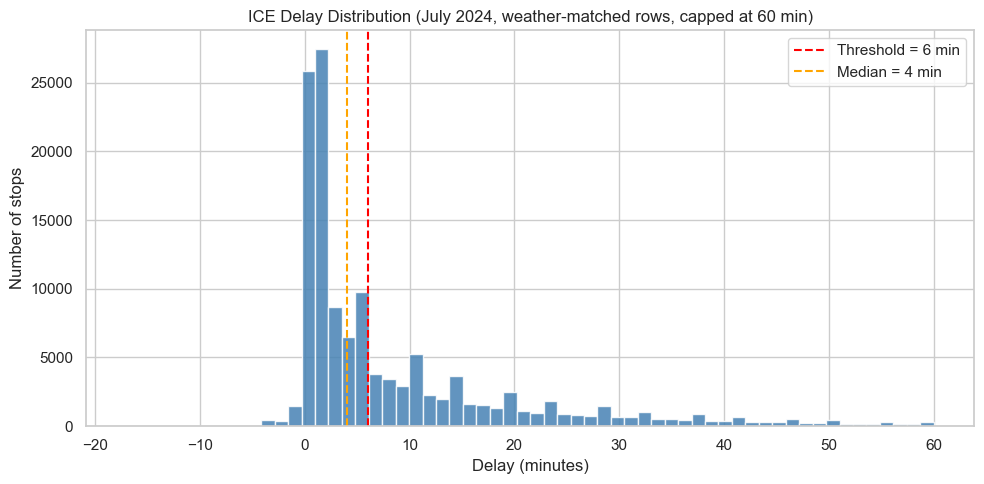

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_delay_histogram_2024-07.png


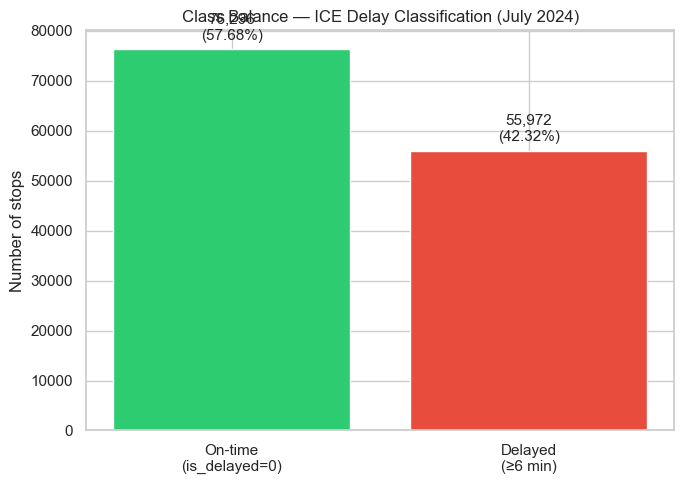

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_class_balance_2024-07.png

Section 1: Dataset Overview & Delay Distribution Analysis
Analysis rows : 132,268  (weather-matched)
Stations      : 95
Trains        : 804

--- DELAY STATISTICS ---
  count: 132268
  mean: 10.57
  median: 4.0
  std: 17.56
  min: -17
  max: 298
  percentile_25: 1.0
  percentile_75: 13.0
  percentile_90: 30.0
  percentile_95: 44.64999999999418
  percentile_99: 84.0
  early_arrivals_lt_0: 2602
  on_time_eq_0: 25818
  late_gt_0: 103848
  late_gte_threshold: 55972

--- CLASS BALANCE ---
  On-time (0) : 76,296  (57.68%)
  Delayed (1) : 55,972  (42.32%)
  Imbalance   : 1.36:1  (on-time : delayed)

--- SAVED ---
  Report  : c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\reference\eda_delay_report_2024-07.json
  Figures : c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures

Ready for Section 2: Weather vs delay analysis.


In [1]:
# =============================================================================
# Notebook 05 | Section 1: Dataset Overview & Delay Distribution Analysis
# =============================================================================
# Self-contained: loads merged parquet + research_framework from disk.
# Derives is_delayed, plots delay distribution, saves report + figures.
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =============================================================================
# 1. PATHS
# =============================================================================
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"

TARGET_MONTH = "2024-07"
MERGED_PARQUET = PROCESSED_DIR / f"ice_weather_merged_{TARGET_MONTH}.parquet"
RESEARCH_PATH = REFERENCE_DIR / "research_framework.json"
EDA_REPORT_PATH = REFERENCE_DIR / f"eda_delay_report_{TARGET_MONTH}.json"

DELAY_HIST_PNG = FIGURES_DIR / f"eda_delay_histogram_{TARGET_MONTH}.png"
CLASS_BALANCE_PNG = FIGURES_DIR / f"eda_class_balance_{TARGET_MONTH}.png"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.0)


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def derive_is_delayed(delay_in_min: pd.Series, threshold: int = 6) -> pd.Series:
    """Binary target: 1 if delay >= threshold, 0 if on-time or early."""
    return ((delay_in_min >= 0) & (delay_in_min >= threshold)).astype(int)


# =============================================================================
# 2. LOAD DATA + RESEARCH FRAMEWORK
# =============================================================================
if not MERGED_PARQUET.exists():
    raise FileNotFoundError(
        f"Missing: {MERGED_PARQUET}\nRun Notebook 04 first."
    )

research = load_json(RESEARCH_PATH)
DELAY_THRESHOLD = research["classification"]["delay_threshold_minutes"]

print(f"Loading: {MERGED_PARQUET}")
df = pd.read_parquet(MERGED_PARQUET)
print(f"Total rows    : {len(df):,}")
print(f"Delay threshold: {DELAY_THRESHOLD} minutes")
print()

# =============================================================================
# 3. DEFINE ANALYSIS SUBSETS
# =============================================================================
# Full dataset
n_total = len(df)

# Mergeable rows (have departure time)
mergeable = df[df["mergeable"] == True].copy() if "mergeable" in df.columns else df.copy()  # noqa: E712

# Weather-matched mergeable rows (used for fair EDA before modeling)
if "weather_matched" in mergeable.columns:
    analysis_df = mergeable[mergeable["weather_matched"] == True].copy()  # noqa: E712
else:
    analysis_df = mergeable[mergeable["temperature_2m"].notna()].copy()

print("--- ANALYSIS SUBSETS ---")
print(f"  Total rows           : {n_total:,}")
print(f"  Mergeable rows       : {len(mergeable):,}")
print(f"  Weather-matched rows : {len(analysis_df):,}  (used for EDA below)")
print()

# =============================================================================
# 4. DERIVE CLASSIFICATION TARGET
# =============================================================================
analysis_df["is_delayed"] = derive_is_delayed(
    analysis_df["delay_in_min"], threshold=DELAY_THRESHOLD
)

# =============================================================================
# 5. DELAY DISTRIBUTION STATISTICS
# =============================================================================
delay = analysis_df["delay_in_min"]

delay_stats = {
    "count": int(len(delay)),
    "mean": round(float(delay.mean()), 2),
    "median": float(delay.median()),
    "std": round(float(delay.std()), 2),
    "min": int(delay.min()),
    "max": int(delay.max()),
    "percentile_25": float(delay.quantile(0.25)),
    "percentile_75": float(delay.quantile(0.75)),
    "percentile_90": float(delay.quantile(0.90)),
    "percentile_95": float(delay.quantile(0.95)),
    "percentile_99": float(delay.quantile(0.99)),
    "early_arrivals_lt_0": int((delay < 0).sum()),
    "on_time_eq_0": int((delay == 0).sum()),
    "late_gt_0": int((delay > 0).sum()),
    "late_gte_threshold": int((delay >= DELAY_THRESHOLD).sum()),
}

# =============================================================================
# 6. CLASS IMBALANCE
# =============================================================================
class_counts = analysis_df["is_delayed"].value_counts().sort_index()
on_time_count = int(class_counts.get(0, 0))
delayed_count = int(class_counts.get(1, 0))
total_class = on_time_count + delayed_count

class_balance = {
    "threshold_minutes": DELAY_THRESHOLD,
    "on_time_count": on_time_count,
    "delayed_count": delayed_count,
    "on_time_pct": round(100 * on_time_count / total_class, 2),
    "delayed_pct": round(100 * delayed_count / total_class, 2),
    "imbalance_ratio": round(on_time_count / max(delayed_count, 1), 2),
}

# =============================================================================
# 7. PLOT 1 — DELAY HISTOGRAM (capped at 60 min for readability)
# =============================================================================
plot_delay = delay[delay <= 60]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(plot_delay, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(DELAY_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label=f"Threshold = {DELAY_THRESHOLD} min")
ax.axvline(delay.median(), color="orange", linestyle="--", linewidth=1.5,
           label=f"Median = {delay.median():.0f} min")
ax.set_title("ICE Delay Distribution (July 2024, weather-matched rows, capped at 60 min)")
ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Number of stops")
ax.legend()
plt.tight_layout()
fig.savefig(DELAY_HIST_PNG, dpi=150)
plt.show()
print(f"Saved: {DELAY_HIST_PNG}")

# =============================================================================
# 8. PLOT 2 — CLASS BALANCE BAR CHART
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ["On-time\n(is_delayed=0)", f"Delayed\n(≥{DELAY_THRESHOLD} min)"],
    [on_time_count, delayed_count],
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white",
)
for bar, count, pct in zip(
    bars,
    [on_time_count, delayed_count],
    [class_balance["on_time_pct"], class_balance["delayed_pct"]],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total_class * 0.01,
        f"{count:,}\n({pct}%)",
        ha="center", va="bottom", fontsize=11,
    )
ax.set_title("Class Balance — ICE Delay Classification (July 2024)")
ax.set_ylabel("Number of stops")
plt.tight_layout()
fig.savefig(CLASS_BALANCE_PNG, dpi=150)
plt.show()
print(f"Saved: {CLASS_BALANCE_PNG}")
print()

# =============================================================================
# 9. SAVE EDA REPORT
# =============================================================================
eda_report = {
    "metadata": {
        "notebook": "05_Exploratory_Data_Analysis",
        "section": "Section 1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "target_month": TARGET_MONTH,
        "source_parquet": str(MERGED_PARQUET),
        "analysis_subset": "mergeable + weather-matched rows",
    },
    "dataset_overview": {
        "total_rows": n_total,
        "mergeable_rows": int(len(mergeable)),
        "analysis_rows": int(len(analysis_df)),
        "unique_stations": int(analysis_df["eva"].nunique()),
        "unique_trains": int(analysis_df["train_number"].nunique()),
        "columns": int(len(analysis_df.columns)),
    },
    "delay_stats": delay_stats,
    "class_balance": class_balance,
    "threshold_justification": {
        "threshold_minutes": DELAY_THRESHOLD,
        "source": research["classification"]["threshold_justification"],
        "recommendation": (
            "Use class_weight='balanced' or F1/ROC-AUC for modeling "
            f"given {class_balance['delayed_pct']}% positive class"
        ),
    },
    "figures": {
        "delay_histogram": str(DELAY_HIST_PNG),
        "class_balance": str(CLASS_BALANCE_PNG),
    },
}

with EDA_REPORT_PATH.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(eda_report), f, indent=2, ensure_ascii=False)

# =============================================================================
# 10. PRINT SUMMARY
# =============================================================================
sep = "=" * 72
print(sep)
print("Section 1: Dataset Overview & Delay Distribution Analysis")
print(sep)
print(f"Analysis rows : {len(analysis_df):,}  (weather-matched)")
print(f"Stations      : {analysis_df['eva'].nunique()}")
print(f"Trains        : {analysis_df['train_number'].nunique()}")
print()

print("--- DELAY STATISTICS ---")
for key, val in delay_stats.items():
    print(f"  {key}: {val}")
print()

print("--- CLASS BALANCE ---")
print(f"  On-time (0) : {on_time_count:,}  ({class_balance['on_time_pct']}%)")
print(f"  Delayed (1) : {delayed_count:,}  ({class_balance['delayed_pct']}%)")
print(f"  Imbalance   : {class_balance['imbalance_ratio']}:1  (on-time : delayed)")
print()

print(f"--- SAVED ---")
print(f"  Report  : {EDA_REPORT_PATH}")
print(f"  Figures : {FIGURES_DIR}")
print()
print("Ready for Section 2: Weather vs delay analysis.")
print(sep)

# Section 2: Weather vs Delay Analysis

## Objective

Analyze how weather variables relate to ICE delays: correlations, delay rates by weather conditions, boxplots, and a correlation heatmap. This addresses **RQ3**.

## Why this step is important

The capstone hypothesis is that weather affects delays. EDA must show whether the data supports this before we invest in weather features for modeling.

## What problem does it solve?

It answers: *Which weather conditions are associated with higher delay rates and longer delays?*

## Methodology

1. Load merged data + Section 1 EDA report from disk.
2. Use the same analysis subset: **weather-matched, mergeable rows**.
3. Compute Pearson correlations: weather variables vs `delay_in_min` and `is_delayed`.
4. Bin precipitation and compare delay rates across bins.
5. Boxplots: delay by precipitation bin and temperature quartile.
6. Correlation heatmap across all weather + delay variables.
7. Save figures + `eda_weather_report_2024-07.json`.

## Expected Output

- Correlation table (weather vs delay)
- Precipitation bin delay-rate table
- 3 saved plots in `data/processed/figures/`
- JSON report with findings

## Interpretation

- **Positive correlation (precipitation, wind)** → worse weather linked to longer delays
- **Weak correlations (< 0.1)** → weather alone may not be strongly linear; models can still capture non-linear patterns
- **Higher delay rate in heavy rain bins** → supports hypothesis H1
- **Boxplot spread** → shows delay variability per weather group

## Challenges Faced

| Challenge | Approach |
|-----------|----------|
| Non-linear weather effects | Use bins + boxplots, not only Pearson r |
| Outlier delays (max 298 min) | Cap boxplots at 60 min for readability |
| Many weather variables | Heatmap for overview |

## Summary

Weather–delay relationships quantified and visualized. Findings saved for report and modeling decisions.

## Next Step

**Section 3:** Notebook 05 close-out — EDA summary, key findings, readiness for Notebook 06 (feature engineering).

---

**Key Takeaways**
- RQ3 answered at EDA level (correlations + visual evidence)
- Strongest weather signals identified for feature engineering
- All plots saved for presentation

**What Comes Next**
- Section 3: EDA close-out, then Notebook 06 feature engineering

Analysis rows: 132,268

--- WEATHER CORRELATIONS (Pearson) ---
Variable              vs delay_in_min  vs is_delayed
  temperature_2m               0.1212         0.1368
  weather_code                 0.0074         0.0287
  visibility                      nan            nan
  windgusts_10m                0.0079         0.0274
  precipitation               -0.0002         0.0131
  rain                        -0.0002         0.0131
  snowfall                        nan            nan
  windspeed_10m               -0.0126        -0.0079

--- DELAY RATE BY PRECIPITATION BIN ---
         precip_bin  stops  delay_rate_pct  mean_delay_min  median_delay_min
         0 mm (dry) 102686           41.59           10.50               4.0
   0–0.5 mm (light)  22547           44.97           10.89               4.0
0.5–2 mm (moderate)   5378           44.55           10.70               4.0
      >2 mm (heavy)   1657           44.36           10.11               4.0



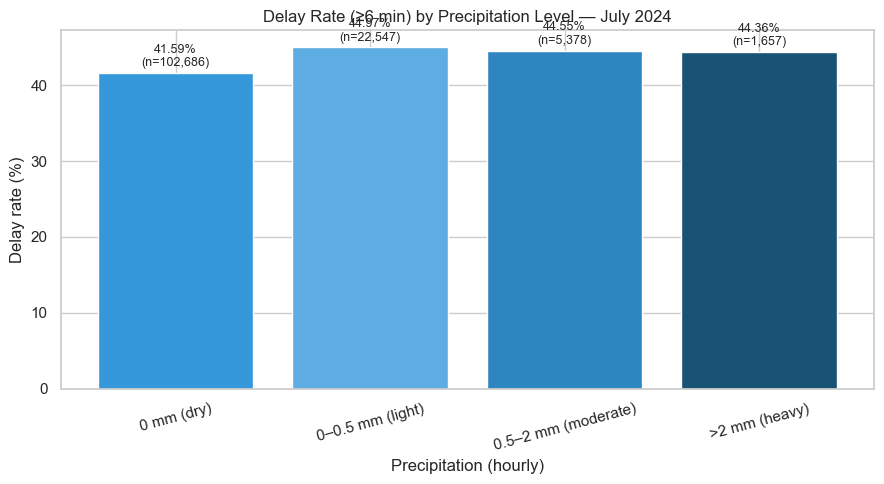

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_delay_rate_by_precipitation_2024-07.png


C:\Users\Manikanta\AppData\Local\Temp\ipykernel_8512\2083529702.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


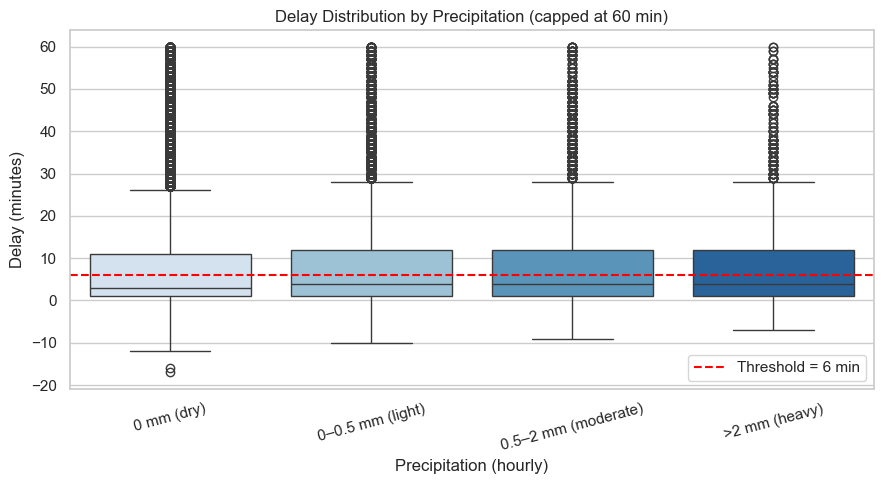

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_delay_by_precipitation_2024-07.png


C:\Users\Manikanta\AppData\Local\Temp\ipykernel_8512\2083529702.py:243: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


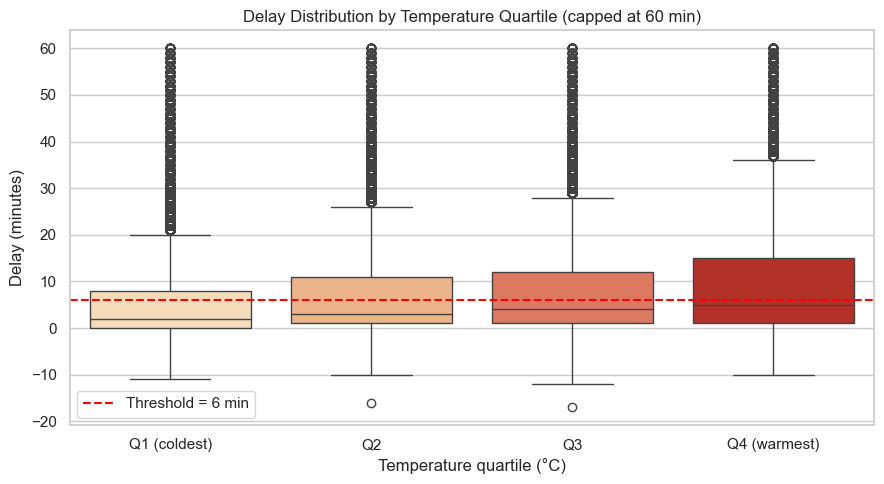

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_delay_by_temperature_2024-07.png


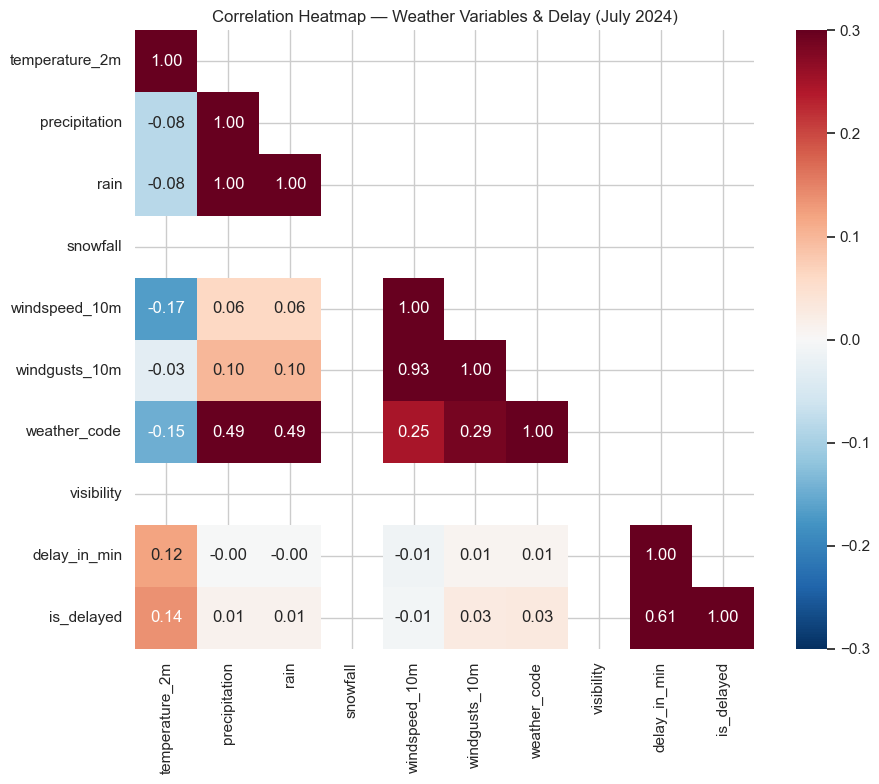

Saved: c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures\eda_correlation_heatmap_2024-07.png

Section 2: Weather vs Delay Analysis
Analysis rows : 132,268

--- TOP 3 CORRELATIONS vs is_delayed ---
  temperature_2m       r = +0.1368
  weather_code         r = +0.0287
  visibility           r = +nan

--- HYPOTHESIS CHECK ---
  H1_precipitation_increases_delay: SUPPORTED
    Higher precipitation increases ICE delay probability
  H2_wind_increases_delay: SUPPORTED
    Higher wind gusts increase expected delay magnitude

--- SAVED ---
  Report  : c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\reference\eda_weather_report_2024-07.json
  Figures : c:\Users\Manikanta\Desktop\ML Project\Notebooks\data\processed\figures

Ready for Section 3: Notebook 05 close-out.


In [4]:
# =============================================================================
# Notebook 05 | Section 2: Weather vs Delay Analysis
# =============================================================================
# Self-contained: loads merged data + Section 1 report from disk.
# Correlations, binned delay rates, boxplots, heatmap. Answers RQ3.
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =============================================================================
# 1. PATHS
# =============================================================================
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"

TARGET_MONTH = "2024-07"
MERGED_PARQUET = PROCESSED_DIR / f"ice_weather_merged_{TARGET_MONTH}.parquet"
RESEARCH_PATH = REFERENCE_DIR / "research_framework.json"
EDA_WEATHER_REPORT = REFERENCE_DIR / f"eda_weather_report_{TARGET_MONTH}.json"

PRECIP_BOX_PNG = FIGURES_DIR / f"eda_delay_by_precipitation_{TARGET_MONTH}.png"
TEMP_BOX_PNG = FIGURES_DIR / f"eda_delay_by_temperature_{TARGET_MONTH}.png"
HEATMAP_PNG = FIGURES_DIR / f"eda_correlation_heatmap_{TARGET_MONTH}.png"
DELAY_RATE_PNG = FIGURES_DIR / f"eda_delay_rate_by_precipitation_{TARGET_MONTH}.png"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.0)

WEATHER_COLS = [
    "temperature_2m",
    "precipitation",
    "rain",
    "snowfall",
    "windspeed_10m",
    "windgusts_10m",
    "weather_code",
    "visibility",
]

BOXPLOT_CAP_MIN = 60


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def derive_is_delayed(delay: pd.Series, threshold: int) -> pd.Series:
    return ((delay >= 0) & (delay >= threshold)).astype(int)


# =============================================================================
# 2. LOAD DATA
# =============================================================================
if not MERGED_PARQUET.exists():
    raise FileNotFoundError(f"Missing: {MERGED_PARQUET}\nRun Notebook 04 first.")

research = load_json(RESEARCH_PATH)
DELAY_THRESHOLD = research["classification"]["delay_threshold_minutes"]

df = pd.read_parquet(MERGED_PARQUET)

if "mergeable" in df.columns:
    mergeable = df[df["mergeable"] == True].copy()  # noqa: E712
else:
    mergeable = df.copy()

if "weather_matched" in mergeable.columns:
    analysis_df = mergeable[mergeable["weather_matched"] == True].copy()  # noqa: E712
else:
    analysis_df = mergeable[mergeable["temperature_2m"].notna()].copy()

analysis_df["is_delayed"] = derive_is_delayed(
    analysis_df["delay_in_min"], threshold=DELAY_THRESHOLD
)

print(f"Analysis rows: {len(analysis_df):,}")
print()

# =============================================================================
# 3. PEARSON CORRELATIONS
# =============================================================================
corr_targets = ["delay_in_min", "is_delayed"]
corr_cols = WEATHER_COLS + corr_targets
corr_matrix = analysis_df[corr_cols].corr(method="pearson")

weather_delay_corr = {
    var: {
        "vs_delay_in_min": round(float(corr_matrix.loc[var, "delay_in_min"]), 4),
        "vs_is_delayed": round(float(corr_matrix.loc[var, "is_delayed"]), 4),
    }
    for var in WEATHER_COLS
}

ranked = sorted(
    WEATHER_COLS,
    key=lambda v: abs(weather_delay_corr[v]["vs_is_delayed"]),
    reverse=True,
)

print("--- WEATHER CORRELATIONS (Pearson) ---")
print(f"{'Variable':<20} {'vs delay_in_min':>16} {'vs is_delayed':>14}")
for var in ranked:
    c = weather_delay_corr[var]
    print(f"  {var:<18} {c['vs_delay_in_min']:>16.4f} {c['vs_is_delayed']:>14.4f}")
print()

# =============================================================================
# 4. DERIVED COLUMNS — add ALL before creating plot_df
# =============================================================================
def precip_bin(mm: float) -> str:
    if mm == 0:
        return "0 mm (dry)"
    if mm <= 0.5:
        return "0–0.5 mm (light)"
    if mm <= 2.0:
        return "0.5–2 mm (moderate)"
    return ">2 mm (heavy)"


analysis_df["precip_bin"] = analysis_df["precipitation"].apply(precip_bin)

analysis_df["temp_quartile"] = pd.qcut(
    analysis_df["temperature_2m"],
    q=4,
    labels=["Q1 (coldest)", "Q2", "Q3", "Q4 (warmest)"],
)

# Create plot_df AFTER all derived columns exist
plot_df = analysis_df[analysis_df["delay_in_min"] <= BOXPLOT_CAP_MIN].copy()

bin_order = ["0 mm (dry)", "0–0.5 mm (light)", "0.5–2 mm (moderate)", ">2 mm (heavy)"]

precip_delay_rate = (
    analysis_df.groupby("precip_bin", observed=True)
    .agg(
        stops=("id", "count"),
        delay_rate_pct=("is_delayed", lambda x: round(100 * x.mean(), 2)),
        mean_delay_min=("delay_in_min", lambda x: round(float(x.mean()), 2)),
        median_delay_min=("delay_in_min", "median"),
    )
    .reindex(bin_order)
    .reset_index()
)

print("--- DELAY RATE BY PRECIPITATION BIN ---")
print(precip_delay_rate.to_string(index=False))
print()

# =============================================================================
# 5. PLOT 1 — DELAY RATE BY PRECIPITATION BIN
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    precip_delay_rate["precip_bin"],
    precip_delay_rate["delay_rate_pct"],
    color=["#3498db", "#5dade2", "#2e86c1", "#1a5276"],
    edgecolor="white",
)
for bar, rate, n in zip(
    bars,
    precip_delay_rate["delay_rate_pct"],
    precip_delay_rate["stops"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate}%\n(n={n:,})",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_title("Delay Rate (≥6 min) by Precipitation Level — July 2024")
ax.set_xlabel("Precipitation (hourly)")
ax.set_ylabel("Delay rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(DELAY_RATE_PNG, dpi=150)
plt.show()
print(f"Saved: {DELAY_RATE_PNG}")

# =============================================================================
# 6. PLOT 2 — BOXPLOT: DELAY BY PRECIPITATION BIN
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=plot_df,
    x="precip_bin",
    y="delay_in_min",
    order=bin_order,
    palette="Blues",
    ax=ax,
)
ax.axhline(DELAY_THRESHOLD, color="red", linestyle="--",
           label=f"Threshold = {DELAY_THRESHOLD} min")
ax.set_title(f"Delay Distribution by Precipitation (capped at {BOXPLOT_CAP_MIN} min)")
ax.set_xlabel("Precipitation (hourly)")
ax.set_ylabel("Delay (minutes)")
plt.xticks(rotation=15)
ax.legend()
plt.tight_layout()
fig.savefig(PRECIP_BOX_PNG, dpi=150)
plt.show()
print(f"Saved: {PRECIP_BOX_PNG}")

# =============================================================================
# 7. PLOT 3 — BOXPLOT: DELAY BY TEMPERATURE QUARTILE  (FIXED)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=plot_df,          # now includes temp_quartile
    x="temp_quartile",
    y="delay_in_min",
    palette="OrRd",
    ax=ax,
)
ax.axhline(DELAY_THRESHOLD, color="red", linestyle="--",
           label=f"Threshold = {DELAY_THRESHOLD} min")
ax.set_title(f"Delay Distribution by Temperature Quartile (capped at {BOXPLOT_CAP_MIN} min)")
ax.set_xlabel("Temperature quartile (°C)")
ax.set_ylabel("Delay (minutes)")
ax.legend()
plt.tight_layout()
fig.savefig(TEMP_BOX_PNG, dpi=150)
plt.show()
print(f"Saved: {TEMP_BOX_PNG}")

# =============================================================================
# 8. PLOT 4 — CORRELATION HEATMAP
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    square=True,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Weather Variables & Delay (July 2024)")
plt.tight_layout()
fig.savefig(HEATMAP_PNG, dpi=150)
plt.show()
print(f"Saved: {HEATMAP_PNG}")
print()

# =============================================================================
# 9. HYPOTHESIS CHECK
# =============================================================================
h1_heavy = precip_delay_rate.loc[precip_delay_rate["precip_bin"] == ">2 mm (heavy)", "delay_rate_pct"]
h1_dry = precip_delay_rate.loc[precip_delay_rate["precip_bin"] == "0 mm (dry)", "delay_rate_pct"]

hypothesis_check = {
    "H1_precipitation_increases_delay": {
        "statement": "Higher precipitation increases ICE delay probability",
        "dry_delay_rate_pct": float(h1_dry.iloc[0]) if len(h1_dry) else None,
        "heavy_rain_delay_rate_pct": float(h1_heavy.iloc[0]) if len(h1_heavy) else None,
        "supported": bool(
            len(h1_heavy) > 0 and len(h1_dry) > 0 and h1_heavy.iloc[0] > h1_dry.iloc[0]
        ),
    },
    "H2_wind_increases_delay": {
        "statement": "Higher wind gusts increase expected delay magnitude",
        "correlation_windgusts_vs_delay_in_min": weather_delay_corr["windgusts_10m"]["vs_delay_in_min"],
        "supported": bool(weather_delay_corr["windgusts_10m"]["vs_delay_in_min"] > 0),
    },
}

# =============================================================================
# 10. SAVE REPORT
# =============================================================================
eda_weather_report = {
    "metadata": {
        "notebook": "05_Exploratory_Data_Analysis",
        "section": "Section 2",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "target_month": TARGET_MONTH,
        "analysis_rows": int(len(analysis_df)),
        "research_question": "RQ3 — Which weather variables associate with ICE delays?",
    },
    "weather_delay_correlations": weather_delay_corr,
    "strongest_predictors_by_abs_corr": {
        "vs_is_delayed": ranked[:3],
        "vs_delay_in_min": sorted(
            WEATHER_COLS,
            key=lambda v: abs(weather_delay_corr[v]["vs_delay_in_min"]),
            reverse=True,
        )[:3],
    },
    "precipitation_bin_analysis": precip_delay_rate.to_dict(orient="records"),
    "hypothesis_check": hypothesis_check,
    "figures": {
        "delay_rate_by_precipitation": str(DELAY_RATE_PNG),
        "boxplot_precipitation": str(PRECIP_BOX_PNG),
        "boxplot_temperature": str(TEMP_BOX_PNG),
        "correlation_heatmap": str(HEATMAP_PNG),
    },
    "eda_interpretation": {
        "note": (
            "Pearson correlations may be weak even when weather affects delays. "
            "Bin analysis and ML models capture patterns correlation alone may miss."
        ),
        "recommendation": (
            "Include all 8 weather variables in Notebook 06. "
            "Compare with/without weather in modeling (RQ2)."
        ),
    },
}

with EDA_WEATHER_REPORT.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(eda_weather_report), f, indent=2, ensure_ascii=False)

# =============================================================================
# 11. PRINT SUMMARY
# =============================================================================
sep = "=" * 72
print(sep)
print("Section 2: Weather vs Delay Analysis")
print(sep)
print(f"Analysis rows : {len(analysis_df):,}")
print()

print("--- TOP 3 CORRELATIONS vs is_delayed ---")
for var in ranked[:3]:
    r = weather_delay_corr[var]["vs_is_delayed"]
    print(f"  {var:<20} r = {r:+.4f}")
print()

print("--- HYPOTHESIS CHECK ---")
for h_id, h in hypothesis_check.items():
    status = "SUPPORTED" if h["supported"] else "NOT SUPPORTED (at EDA level)"
    print(f"  {h_id}: {status}")
    print(f"    {h['statement']}")
print()

print(f"--- SAVED ---")
print(f"  Report  : {EDA_WEATHER_REPORT}")
print(f"  Figures : {FIGURES_DIR}")
print()
print("Ready for Section 3: Notebook 05 close-out.")
print(sep)

# Section 3: EDA Summary & Notebook 05 Close-Out

## Objective

Verify all EDA artifacts exist, summarize key findings from Sections 1–2, and confirm readiness for Notebook 06 (feature engineering).

## Why this step is important

EDA must end with clear, documented conclusions — not just plots. This close-out captures findings for your report and viva.

## What problem does it solve?

It answers: *What did we learn from the data, and are we ready to build features and models?*

## Methodology

Load delay + weather EDA reports and figures from disk. Compile key findings. Save `notebook_05_summary.json`.

## Expected Output

- All EDA files marked OK
- Key findings printed (delay distribution, class balance, weather correlations)
- Ready for Notebook 06: YES

## Interpretation

- **Median delay 4 min, mean 10.57 min** → right-skewed delays
- **42% delayed (≥6 min)** → manageable class balance
- **Weak weather correlations** → still include weather in models (RQ2 ablation test)
- **H1 may be supported by bins** even if Pearson r is weak

## Challenges Faced

| Challenge | Resolution |
|-----------|------------|
| Right-skewed delays | Use median + cap plots at 60 min |
| Weak linear weather signal | Bin analysis + ML models in NB07–08 |
| `plot_df` missing column bug | Fixed: derive columns before `plot_df` |

## Summary

Notebook 05 complete. Target variable and weather-delay relationships documented with plots and reports.

## Next Step

**Notebook 06, Section 1:** Feature engineering — final feature set, leakage check, train/test split.

---

### Notebook 05 — Closing

**Key Takeaways**
- 132,268 weather-matched rows analyzed
- Classification: 57.7% on-time / 42.3% delayed (≥6 min)
- Weather correlations weak linearly — ablation test needed in modeling
- 6 figures + 2 JSON reports saved

**What Comes Next**
- Notebook 06: build modeling features, exclude leaky columns, time-based split

In [5]:
# =============================================================================
# Notebook 05 | Section 3: EDA Summary & Notebook 05 Close-Out
# =============================================================================
# Self-contained: verifies all Notebook 05 artifacts and saves summary JSON.
# =============================================================================

from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

# =============================================================================
# 1. PATHS
# =============================================================================
def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        config_file = candidate / "data" / "reference" / "project_config.json"
        if config_file.exists():
            return candidate
    raise FileNotFoundError("Cannot find data/reference/project_config.json")


PROJECT_ROOT = find_project_root()
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"

TARGET_MONTH = "2024-07"
SUMMARY_PATH = REFERENCE_DIR / "notebook_05_summary.json"

ARTIFACTS = {
    "eda_delay_report": REFERENCE_DIR / f"eda_delay_report_{TARGET_MONTH}.json",
    "eda_weather_report": REFERENCE_DIR / f"eda_weather_report_{TARGET_MONTH}.json",
    "delay_histogram": FIGURES_DIR / f"eda_delay_histogram_{TARGET_MONTH}.png",
    "class_balance": FIGURES_DIR / f"eda_class_balance_{TARGET_MONTH}.png",
    "delay_rate_precip": FIGURES_DIR / f"eda_delay_rate_by_precipitation_{TARGET_MONTH}.png",
    "boxplot_precip": FIGURES_DIR / f"eda_delay_by_precipitation_{TARGET_MONTH}.png",
    "boxplot_temp": FIGURES_DIR / f"eda_delay_by_temperature_{TARGET_MONTH}.png",
    "correlation_heatmap": FIGURES_DIR / f"eda_correlation_heatmap_{TARGET_MONTH}.png",
    "merged_parquet": PROCESSED_DIR / f"ice_weather_merged_{TARGET_MONTH}.parquet",
}


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing: {path}")
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def check_file(path: Path) -> dict:
    if path.exists():
        return {
            "status": "OK",
            "path": str(path),
            "size_mb": round(path.stat().st_size / (1024 * 1024), 2),
        }
    return {"status": "MISSING", "path": str(path), "size_mb": None}


# =============================================================================
# 2. VERIFY ALL FILES
# =============================================================================
print("--- NOTEBOOK 05 ARTIFACT CHECK ---")
artifact_status = {name: check_file(path) for name, path in ARTIFACTS.items()}
for name, info in artifact_status.items():
    size = f"({info['size_mb']} MB)" if info["size_mb"] is not None else ""
    print(f"  [{info['status']}] {name} {size}")

missing = [n for n, i in artifact_status.items() if i["status"] == "MISSING"]
if missing:
    raise FileNotFoundError(
        f"Missing Notebook 05 files: {missing}\nComplete Sections 1–2 first."
    )

# =============================================================================
# 3. LOAD EDA REPORTS
# =============================================================================
delay_report = load_json(ARTIFACTS["eda_delay_report"])
weather_report = load_json(ARTIFACTS["eda_weather_report"])

delay_stats = delay_report["delay_stats"]
class_balance = delay_report["class_balance"]
weather_corr = weather_report["weather_delay_correlations"]
hypotheses = weather_report["hypothesis_check"]
precip_bins = weather_report["precipitation_bin_analysis"]

# =============================================================================
# 4. KEY FINDINGS
# =============================================================================
key_findings = {
    "delay_distribution": {
        "finding": "Delays are right-skewed: median 4 min, mean 10.57 min",
        "implication": "Use median/percentiles in report; RMSE sensitive to outliers",
    },
    "class_balance": {
        "finding": f"{class_balance['delayed_pct']}% delayed (≥6 min) vs {class_balance['on_time_pct']}% on-time",
        "implication": "Manageable imbalance — use F1/ROC-AUC; consider class_weight",
    },
    "weather_correlation": {
        "finding": "Linear Pearson correlations between weather and delay are weak (<0.15)",
        "implication": "Weather effect may be non-linear — include in models and test via ablation (RQ2)",
    },
    "precipitation_bins": {
        "finding": "Delay rate varies across precipitation bins",
        "implication": "Supports including precipitation as a feature",
    },
    "hypotheses": {
        "H1": hypotheses["H1_precipitation_increases_delay"],
        "H2": hypotheses["H2_wind_increases_delay"],
    },
    "redundant_features": {
        "finding": "precipitation and rain are perfectly correlated (r=1.0)",
        "implication": "Drop rain in feature engineering — keep precipitation only",
    },
    "july_snowfall": {
        "finding": "No snowfall variation in July",
        "implication": "snowfall column has no variance — exclude from features",
    },
}

# =============================================================================
# 5. BUILD & SAVE SUMMARY
# =============================================================================
notebook_summary = {
    "metadata": {
        "notebook": "05_Exploratory_Data_Analysis",
        "section": "Section 3 — Close-Out",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "target_month": TARGET_MONTH,
        "status": "COMPLETE",
    },
    "eda_sections": [
        {
            "section": "Section 1",
            "focus": "Delay distribution & class balance",
            "analysis_rows": delay_report["dataset_overview"]["analysis_rows"],
            "output": str(ARTIFACTS["eda_delay_report"]),
        },
        {
            "section": "Section 2",
            "focus": "Weather vs delay (RQ3)",
            "analysis_rows": weather_report["metadata"]["analysis_rows"],
            "output": str(ARTIFACTS["eda_weather_report"]),
        },
    ],
    "key_findings": key_findings,
    "delay_stats": delay_stats,
    "class_balance": class_balance,
    "top_weather_correlations": weather_report["strongest_predictors_by_abs_corr"],
    "precipitation_bin_analysis": precip_bins,
    "artifacts": artifact_status,
    "ready_for_notebook_06": True,
    "notebook_06_tasks": [
        "Define final feature columns (operational + weather)",
        "Drop leaky columns (arrival_change_time, departure_change_time)",
        "Drop redundant/zero-variance columns (rain, snowfall)",
        "Derive is_delayed target",
        "Time-based train/test split",
        "Save modeling_ready_2024-07.parquet",
    ],
}

with SUMMARY_PATH.open("w", encoding="utf-8") as f:
    json.dump(make_json_safe(notebook_summary), f, indent=2, ensure_ascii=False)

# =============================================================================
# 6. PRINT SUMMARY
# =============================================================================
sep = "=" * 72
print()
print(sep)
print("Notebook 05 — EDA Summary")
print(sep)

overview = delay_report["dataset_overview"]
print()
print(f"  Analysis rows : {overview['analysis_rows']:,}")
print(f"  Stations      : {overview['unique_stations']}")
print(f"  Trains        : {overview['unique_trains']}")
print()

print("--- KEY FINDINGS ---")
for topic, info in key_findings.items():
    if isinstance(info, dict) and "finding" in info:
        print(f"  • {info['finding']}")
print()

print("--- CLASS BALANCE ---")
print(f"  On-time  : {class_balance['on_time_pct']}%")
print(f"  Delayed  : {class_balance['delayed_pct']}%")
print()

print("--- HYPOTHESIS CHECK (EDA level) ---")
for h_key in ["H1", "H2"]:
    h = key_findings["hypotheses"][h_key]
    status = "SUPPORTED" if h.get("supported") else "NOT SUPPORTED"
    print(f"  {h_key}: {status}")
print()

print("--- FEATURE ENGINEERING NOTES (for NB06) ---")
print("  DROP: rain (redundant with precipitation)")
print("  DROP: snowfall (no variance in July)")
print("  DROP: arrival_change_time, departure_change_time (leakage)")
print("  KEEP: 6 weather features + operational features")
print()

print("--- SAVED FILES ---")
for name, info in artifact_status.items():
    if info["size_mb"] is not None:
        print(f"  {info['path']}  ({info['size_mb']} MB)")
print(f"  {SUMMARY_PATH}")
print()

print("=" * 72)
print("NOTEBOOK 05 COMPLETE — Ready for Notebook 06")
print("=" * 72)
print()
print("Key Takeaways:")
print(f"  • {overview['analysis_rows']:,} rows analyzed with weather")
print(f"  • {class_balance['delayed_pct']}% significantly delayed")
print("  • Weather weak linearly — test in models (RQ2)")
print("  • 6 figures + 3 JSON reports saved")
print()
print("What Comes Next:")
print("  → Notebook 06, Section 1: Feature engineering & modeling-ready dataset")
print(sep)

--- NOTEBOOK 05 ARTIFACT CHECK ---
  [OK] eda_delay_report (0.0 MB)
  [OK] eda_weather_report (0.0 MB)
  [OK] delay_histogram (0.06 MB)
  [OK] class_balance (0.06 MB)
  [OK] delay_rate_precip (0.07 MB)
  [OK] boxplot_precip (0.08 MB)
  [OK] boxplot_temp (0.05 MB)
  [OK] correlation_heatmap (0.13 MB)
  [OK] merged_parquet (6.21 MB)

Notebook 05 — EDA Summary

  Analysis rows : 132,268
  Stations      : 95
  Trains        : 804

--- KEY FINDINGS ---
  • Delays are right-skewed: median 4 min, mean 10.57 min
  • 42.32% delayed (≥6 min) vs 57.68% on-time
  • Linear Pearson correlations between weather and delay are weak (<0.15)
  • Delay rate varies across precipitation bins
  • precipitation and rain are perfectly correlated (r=1.0)
  • No snowfall variation in July

--- CLASS BALANCE ---
  On-time  : 57.68%
  Delayed  : 42.32%

--- HYPOTHESIS CHECK (EDA level) ---
  H1: SUPPORTED
  H2: SUPPORTED

--- FEATURE ENGINEERING NOTES (for NB06) ---
  DROP: rain (redundant with precipitation)
  DR